In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path # to handle file paths for better portability

import seaborn as sns
import matplotlib
matplotlib.use('Agg') # Use Agg backend for non-interactive plotting
import matplotlib.pyplot as plt
plt.switch_backend('Agg') # Ensure non-interactive backend is used
%matplotlib inline

import datetime as datetime

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from xgboost import XGBRegressor

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]  # adjust if needed
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'modified_healthcare_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.sample(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
54405,Maria Bender,19,Female,O-,Infections,2022-07-06,Anthony Nash,UI Health (University of Illinois Hospital),Medicare,2970.641757,405,Routine,2022-07-13,Amoxicillin,Abnormal,7
23397,Erik Johnson,38,Male,B-,Infections,2021-07-25,Robert Smith,UChicago Medicine,Blue Cross,1456.750364,445,Emergency,2021-08-03,Ciprofloxacin,Abnormal,9
15792,Susan Jackson,57,Male,AB-,Obesity,2022-10-01,Jennifer Aguilar,Loyola University Medical Center,UnitedHealthcare,8228.968844,146,Elective,2022-10-08,Phentermine,Normal,7
39055,Jacob Perry,73,Female,O+,Cancer,2021-04-13,Larry Bradley,Northwestern Memorial Hospital,Cigna,83720.517470,368,Urgent,2021-05-09,Methotrexate,Inconclusive,26
41424,Martin Moran,28,Male,A+,Flu,2021-12-07,Mary Walker,Loyola University Medical Center,Medicare,902.299785,171,Emergency,2021-12-10,Zanamivir,Abnormal,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
 15  Length of Stay      55500 non-null  int64  
dtypes: f

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,55500.0,48.001622,21.105827,5.000000,32.000000,50.000000,65.000000,90.000000
Billing Amount,55500.0,21835.044635,23574.413594,500.220989,4195.525741,11089.537763,35887.703406,99997.797977
Room Number,55500.0,301.134829,115.243069,101.000000,202.000000,302.000000,401.000000,500.000000
Length of Stay,55500.0,17.841009,20.272294,1.000000,4.000000,8.000000,28.000000,89.000000


In [5]:
# check missing values
missing_values = df.isnull().sum()
print(f'Missing values in each column: {missing_values}')

Missing values in each column: Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Length of Stay        0
dtype: int64


In [6]:
# size of df before
df.shape

(55500, 16)

In [7]:
# size after df dropped nan's
df = df.dropna()
df.shape

(55500, 16)

In [8]:
# Convert date columns into datetime objects
date_cols = ['Date of Admission', 'Discharge Date']
for col in date_cols:
    try: 
        df[col] = pd.to_datetime(df[col], errors='coerce')
    except Exception as e:
        print(f'Erro converting {col}: {e}')
print("Data types after conversion::")
df.dtypes

Data types after conversion::


Name                          object
Age                            int64
Gender                        object
Blood Type                    object
Medical Condition             object
Date of Admission     datetime64[ns]
Doctor                        object
Hospital                      object
Insurance Provider            object
Billing Amount               float64
Room Number                    int64
Admission Type                object
Discharge Date        datetime64[ns]
Medication                    object
Test Results                  object
Length of Stay                 int64
dtype: object

In [9]:
# clean whie stpaces from string columns
str_cols = df.select_dtypes(include=['object']).columns
for col in str_cols:
    df[col] = df[col].str.strip()
print("Whitespace cleaned from string columns.")

Whitespace cleaned from string columns.


Numeric columns for correlation heatmap: ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']


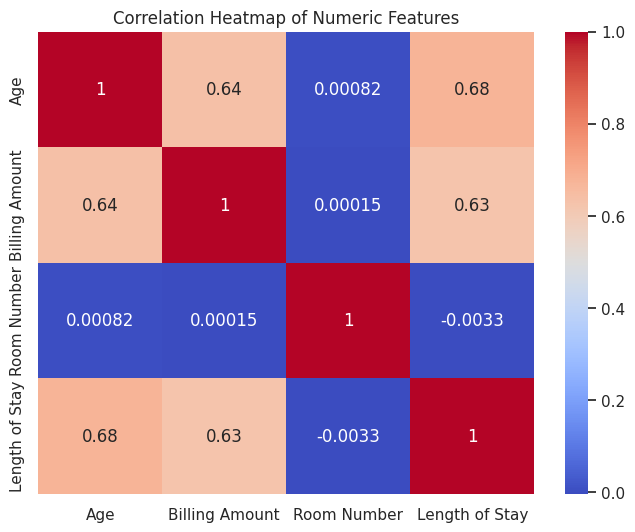

In [10]:
# Heatmap
numeric_df = df.select_dtypes(include=[np.number])
print(f'Numeric columns for correlation heatmap: {numeric_df.columns.tolist()}')

if numeric_df.shape[1] >= 4:
    corr = numeric_df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()
else:
    print("Not enough numeric columns to generate a correlation heatmap.")

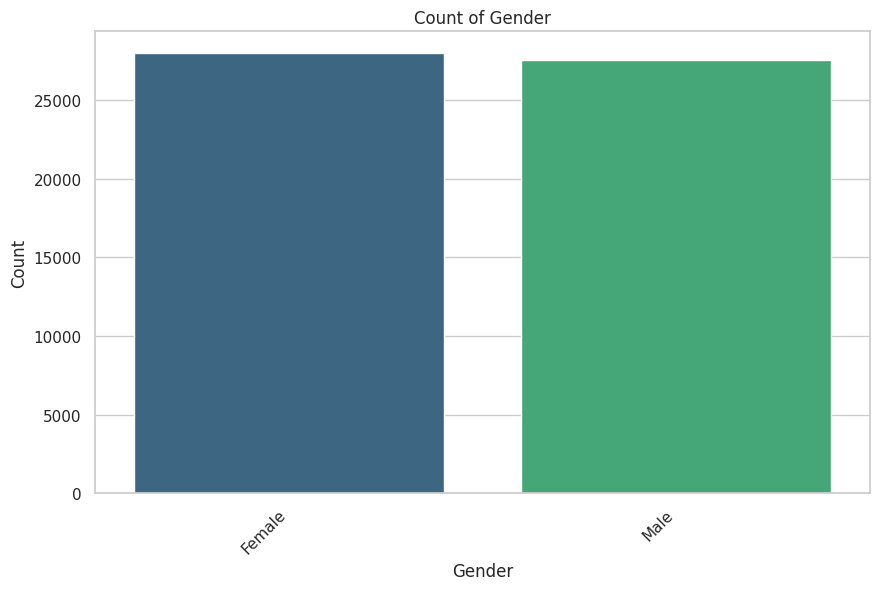

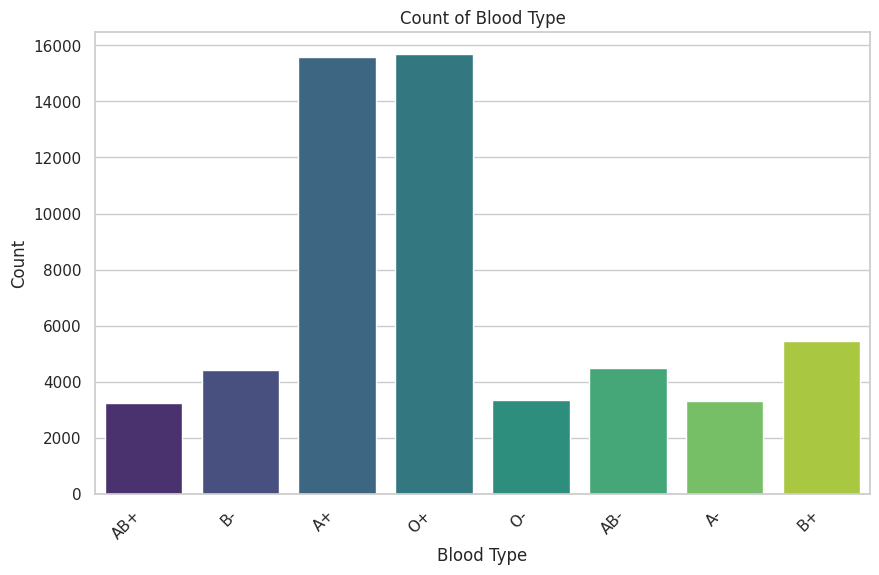

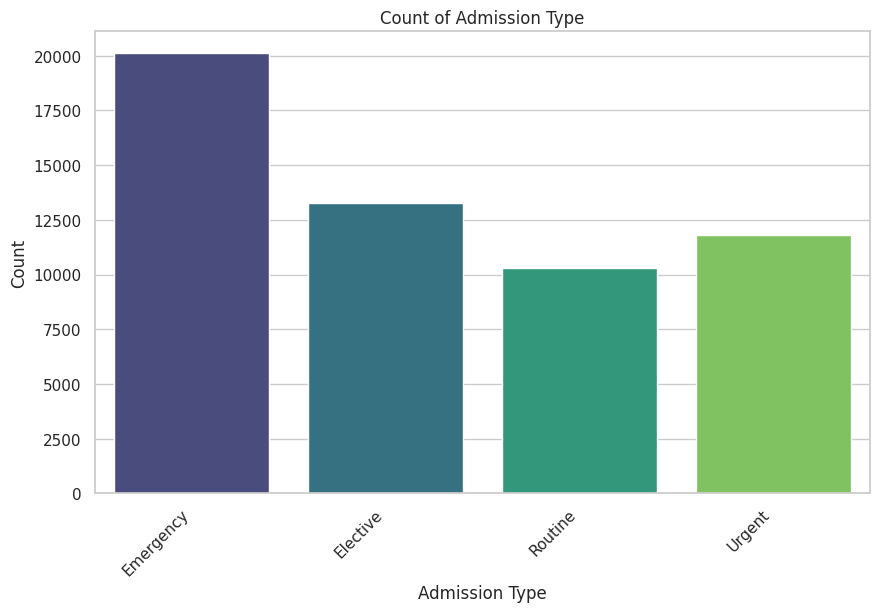

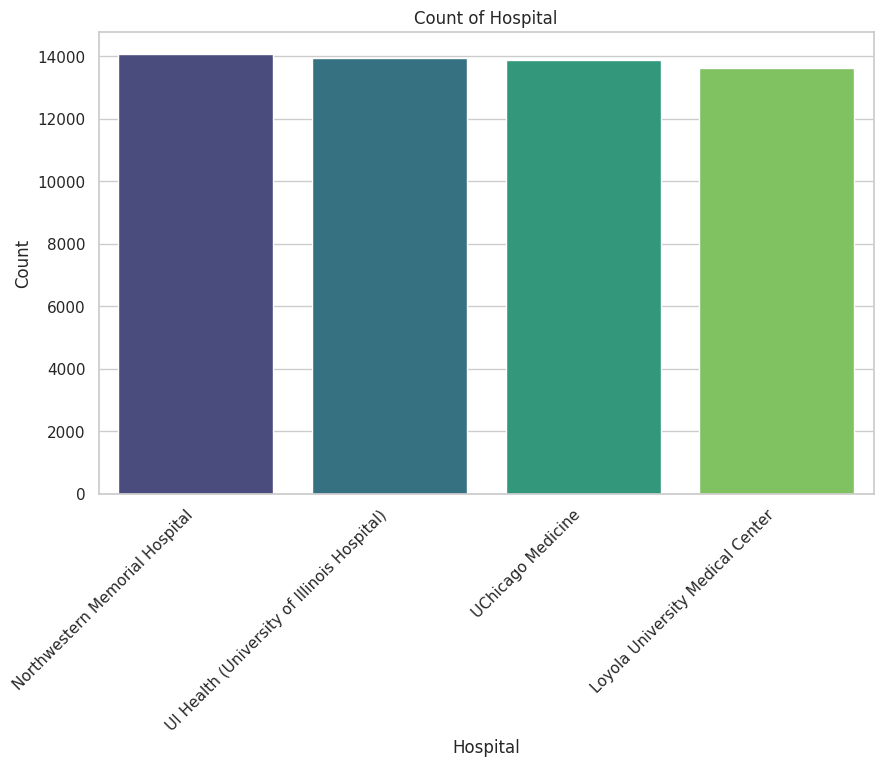

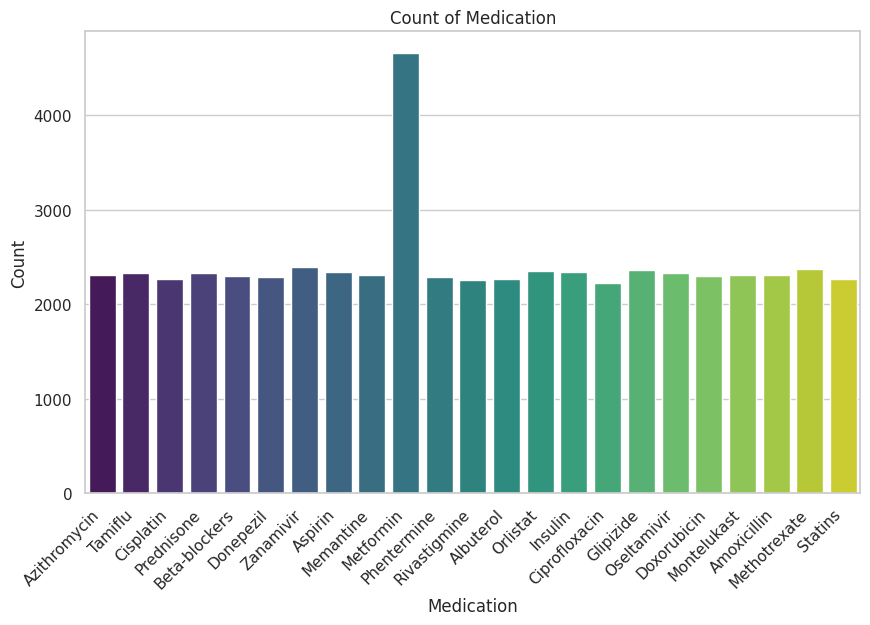

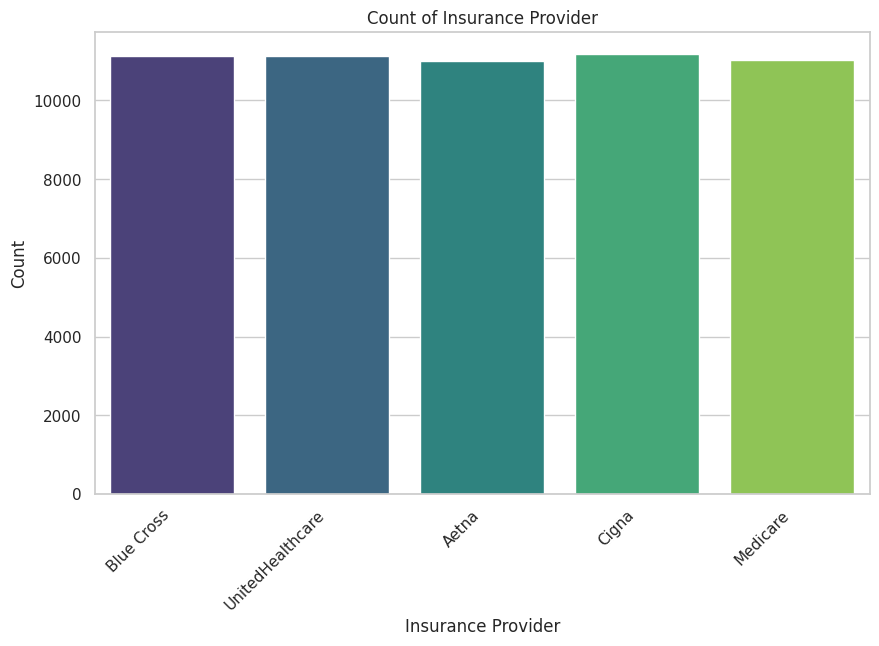

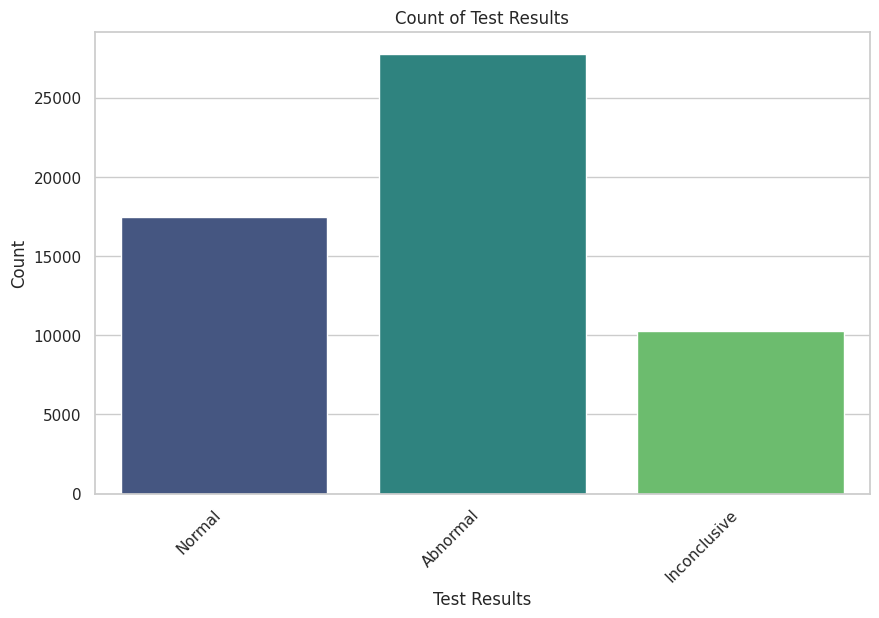

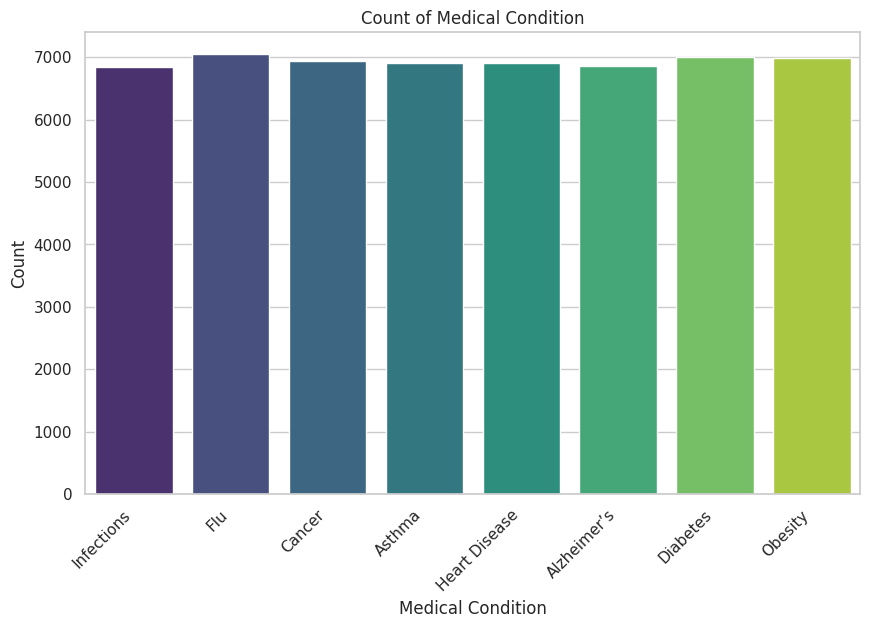

In [11]:
# categorial features count plots
cat_cols = ['Gender', 'Blood Type', 'Admission Type', 'Hospital', 'Medication', 'Insurance Provider', 'Test Results', 'Medical Condition']

for col in cat_cols:
    plt.figure()
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.show()

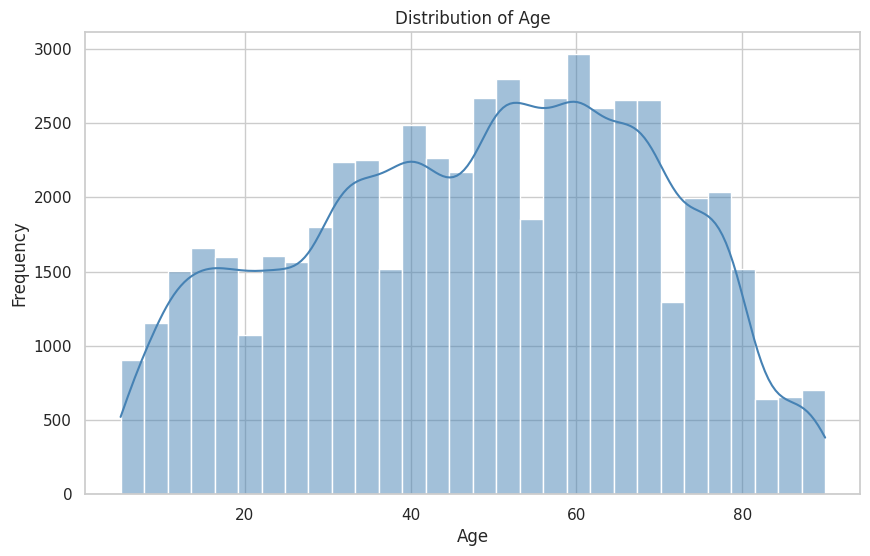

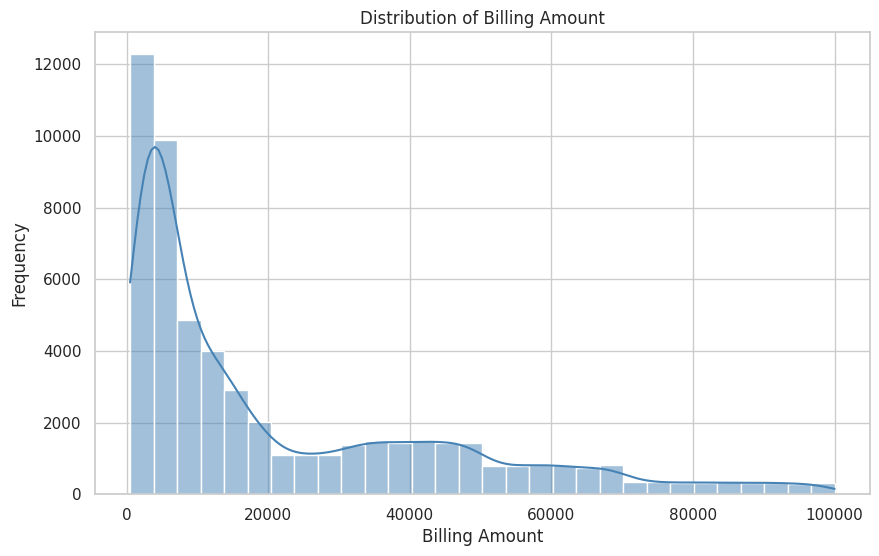

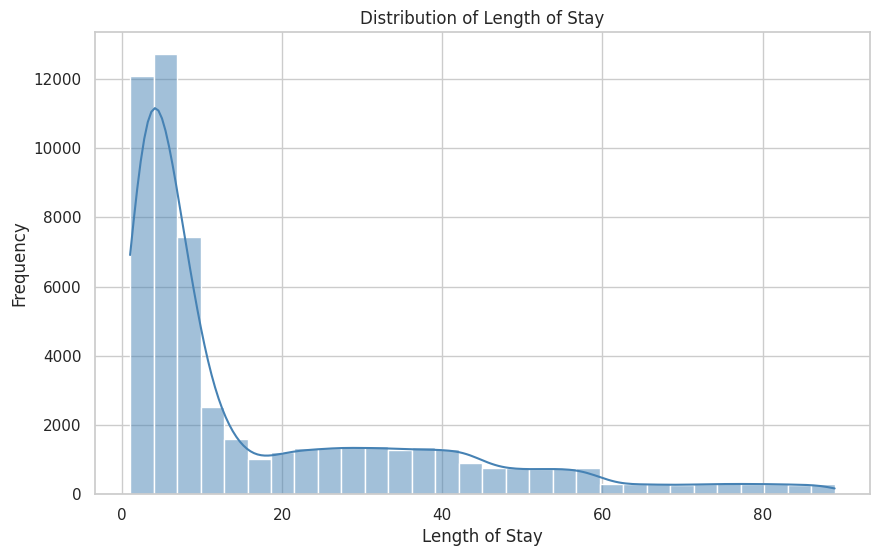

In [12]:
# distribution of age and billing amount
for col in ['Age', 'Billing Amount', 'Length of Stay']:
    plt.figure()
    sns.histplot(df[col], kde=True, color='steelblue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [13]:
df['Doctor'].value_counts()

Doctor
Michael Smith          27
Robert Smith           22
John Smith             22
Michael Johnson        20
James Smith            20
                       ..
Timothy Chapman         1
Terri Collins           1
Jill Jacobson           1
Jesse Combs             1
Christopher Estrada     1
Name: count, Length: 40341, dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [15]:
# Setup for ML with sklearn: columns, split, features
# -------------------------
# CONFIG
# -------------------------
TARGET = "Billing Amount"

DROP_COLS = ["Name", "Doctor", "Room Number"]

cat_cols = [
    "Gender", "Blood Type", "Admission Type", "Hospital", "Medication",
    "Insurance Provider", "Test Results", "Medical Condition"
]

date_cols = ["Date of Admission", "Discharge Date"]

RANDOM_STATE = 42


# -------------------------
# BASIC SANITY
# -------------------------
# Ensure expected columns exist
missing = set([TARGET] + DROP_COLS + cat_cols + date_cols) - set(df.columns)
if missing:
    raise ValueError(f"Missing expected columns: {sorted(missing)}")

# Drop requested columns
df_model = df.drop(columns=DROP_COLS).copy()

# --- Date feature engineering OUTSIDE the pipeline ---
for col in date_cols:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")
    df_model[f"{col}_year"] = df_model[col].dt.year
    df_model[f"{col}_month"] = df_model[col].dt.month
    df_model[f"{col}_dayofweek"] = df_model[col].dt.dayofweek

# Drop original datetime columns now that parts exist
df_model = df_model.drop(columns=date_cols)

# Separate X/y
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].astype(float)

# -------------------------
# TRAIN / VAL / TEST SPLIT
# -------------------------
# 1) Split off TEST (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# 2) Split remaining into TRAIN (80% of trainval) and VAL (20% of trainval)
# This yields: train=64%, val=16%, test=20%
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=RANDOM_STATE
)

print(X_train.shape, X_val.shape, X_test.shape)

(35520, 16) (8880, 16) (11100, 16)


In [16]:
# Preprocessing: sparse one hot encoding, numeric scaling, and date feature extraction

def add_date_parts(X_df: pd.DataFrame) -> pd.DataFrame:
    X_df = X_df.copy()
    for col in date_cols:
        # ensure datetime
        X_df[col] = pd.to_datetime(X_df[col], errors="coerce")
        X_df[f"{col}_year"] = X_df[col].dt.year
        X_df[f"{col}_month"] = X_df[col].dt.month
        X_df[f"{col}_dayofweek"] = X_df[col].dt.dayofweek
    # drop original datetime columns
    X_df = X_df.drop(columns=date_cols)
    return X_df

date_featurizer = FunctionTransformer(add_date_parts, feature_names_out="one-to-one")

# After date expansion, we will treat new date part columns as numeric.
# Determine numeric cols dynamically (after dropping cats + dates):
base_numeric_cols = [c for c in X.columns if c not in cat_cols + date_cols]

# We'll add the engineered date part columns names here:
engineered_date_cols = []
for col in date_cols:
    engineered_date_cols += [f"{col}_year", f"{col}_month", f"{col}_dayofweek"]

# Numeric columns are everything not in cat_cols (since dates are already numeric parts)
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
        ("num", StandardScaler(with_mean=False), num_cols),
    ],
    remainder="drop",
    sparse_threshold=1.0
)


In [17]:
# converts sparse matrix -> dense array; passes through dense unchanged
to_dense = FunctionTransformer(
    lambda X: X.toarray() if hasattr(X, "toarray") else X,
    accept_sparse=True
)

def make_pipeline(model, dense_required: bool):
    steps = [("preprocess", preprocessor)]
    if dense_required:
        steps.append(("to_dense", to_dense))
    steps.append(("model", model))
    return Pipeline(steps=steps)

# Models: baseline + 5 comparative models, 5-fold cv + tuning for regularization

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "LinearRegression (baseline)": {
        "estimator": LinearRegression(),
        "param_grid": {}
    },

    # -------------------------
    # Regularized linear models
    # -------------------------
    "Ridge (L2)": {
        "estimator": Ridge(random_state=RANDOM_STATE),
        "param_grid": {
            "model__alpha": np.logspace(-3, 3, 13)  # 0.001 ... 1000
        }
    },
    "Lasso (L1)": {
        "estimator": Lasso(random_state=RANDOM_STATE, max_iter=50000),
        "param_grid": {
            "model__alpha": np.logspace(-4, 2, 13)  # 0.0001 ... 100
        }
    },
    "ElasticNet (L1+L2)": {
        "estimator": ElasticNet(random_state=RANDOM_STATE, max_iter=50000),
        "param_grid": {
            "model__alpha": np.logspace(-4, 2, 10),
            "model__l1_ratio": [0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
        }
    },

    # -------------------------
    # Tree ensembles (dense-only)
    # -------------------------
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [400, 800, 1200],
            "model__max_depth": [8, 10, 14, 18, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": ["sqrt", "log2", 0.5],
            "model__bootstrap": [True],
        }
    },
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "param_grid": {
            "model__learning_rate": [0.01, 0.03, 0.06, 0.1],
            "model__max_depth": [3, 6, 10, None],
            "model__max_iter": [300, 600, 1000],
            "model__min_samples_leaf": [10, 20, 50, 100],
            "model__l2_regularization": [0.0, 0.1, 1.0, 10.0],
            "model__max_bins": [128, 255],
        }
    },

    # -------------------------
    # XGBoost (sparse-friendly)
    # -------------------------
    "XGBoostRegressor": {
        "estimator": XGBRegressor(
            random_state=RANDOM_STATE,
            objective="reg:squarederror",
            tree_method="hist",      # fast on CPU
            n_jobs=-1,
        ),
        "param_grid": {
            "model__n_estimators": [600, 1200, 2000],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__max_depth": [3, 4, 6, 8],
            "model__min_child_weight": [1, 3, 5, 10],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0],
            "model__reg_alpha": [0.0, 1e-3, 1e-2, 0.1, 1.0],   # L1
            "model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],   # L2
            "model__gamma": [0.0, 0.1, 0.3, 1.0],
        }
    },
}


In [18]:
# train with cv, then compare on validation and test sets
results = []

best_estimators = {}

# mark which models need dense
dense_required_models = {"RandomForest", "HistGradientBoosting"}

for name, spec in models.items():
    dense_required = any(k in name for k in dense_required_models)

    pipe = make_pipeline(spec["estimator"], dense_required=dense_required)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=spec["param_grid"],
        scoring="r2",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_
    best_estimators[name] = best_pipe

    y_val_pred = best_pipe.predict(X_val)
    results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_best_r2": search.best_score_,
        "val_r2": r2_score(y_val, y_val_pred),
        "val_mse": mean_squared_error(y_val, y_val_pred),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
    })

results_df = pd.DataFrame(results).sort_values(by=["val_r2", "val_mse"], ascending=[False, True])
results_df

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 13 candidates, totalling 65 fits
Fitting 5 folds for each of 13 candidates, totalling 65 fits
Fitting 5 folds for each of 70 candidates, totalling 350 fits
Fitting 5 folds for each of 540 candidates, totalling 2700 fits


/home/oem/Documents/github/mit_healthcare_dataset/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/oem/Documents/github/mit_healthcare_dataset/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/oem/Documents/github/mit_healthcare_dataset/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib wor

Fitting 5 folds for each of 1536 candidates, totalling 7680 fits
Fitting 5 folds for each of 172800 candidates, totalling 864000 fits


KeyboardInterrupt: 

In [ ]:
best_model_name = results_df.iloc[0]["model"]
best_model = best_estimators[best_model_name]

y_test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("Best model:", best_model_name)
print(f"TEST R^2:  {test_r2:.4f}")
print(f"TEST MSE:  {test_mse:,.2f}")
print(f"TEST RMSE: {test_rmse:,.2f}")